In [1]:
import os
import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from Geometry_methods import set_geom_fuel_shell,set_mat
# Reset OpenMC internal IDs to avoid duplicates
openmc.reset_auto_ids()

mat = openmc.Materials.from_xml("materials.xml")

new_geom = True
inner_fuel_r = 48
outer_fuel_r = 50
outer_moderater_r = 87

with_blanket = True
blanket_or = 100

inner_moderator_height = 84

if new_geom:
    geom, mat = set_geom_fuel_shell(inner_fuel_r,outer_fuel_r,outer_moderater_r,with_blanket=with_blanket,
                               blanket_or=blanket_or, materials = mat, inner_moderator_height=inner_moderator_height)
else:
    geom = openmc.Geometry.from_xml("geometry.xml")

Fuel_CA_1
Fuel_CA_2
Blanket_CA
Fuel_A
Fuel_B
Fuel_C
Air
h2o
d2o
uo2


In [2]:
fuel_material, heavy_water, water, blanket_CA, air, mat = set_mat("Fuel CA",materials=mat)

Fuel CA_1
Fuel CA_2
Blanket CA
Fuel A
Fuel B
Fuel C
Air
h2o
d2o
uo2


BoundingBox(lower_left=(-100.0, -100.0, -100.0), upper_right=(100.0, 100.0, 100.0))
fuel radius and outer radius are 48.0, 50.0 and  100.0


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

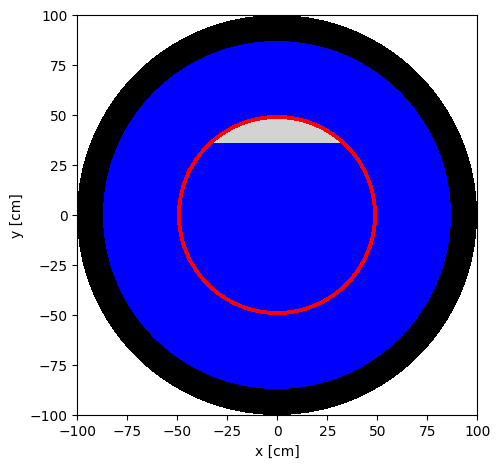

In [3]:
#print(cells)
fuel = geom.get_cells_by_name('fuel')[0]
moderator = geom.get_cells_by_name('moderator')[0]
blanket = geom.get_cells_by_name('blanket')[0]
air_cell = geom.get_cells_by_name('air')[0]

inner_fuel_radius = geom.get_surfaces_by_name('fuel_inner')[0].bounding_box('-')[1][0]
outer_fuel_radius = geom.get_surfaces_by_name('fuel_outer')[0].bounding_box('-')[1][0]
outer_radius = geom.get_surfaces_by_name('outer_sphere')[0].bounding_box('-')[1][0]
print(geom.get_surfaces_by_name('outer_sphere')[0].bounding_box('-'))
print(f'fuel radius and outer radius are {inner_fuel_radius}, {outer_fuel_radius} and  {outer_radius}')

cell_colors = {
    fuel: 'red',
    moderator: 'blue',
    air_cell: "lightgrey",
    blanket: 'black'
    }


geom.plot(
    pixels=(400, 400),       # resolution
    basis='xy',              # plane (xy, xz, yz)
    color_by='cell',     # color by material or cell
    colors = cell_colors
    )

In [4]:
#Tallies
resolution_of_mesh=10
mesh_size = int(outer_radius)
os.system("rm tallies.xml")
# Tally 1: energy spectrum in fuel
cell_filter1 = openmc.CellFilter(fuel)
energybins=np.logspace(-2,7,1001) #1000 bins between 1e-2 eV and 1e7 eV
energy_filter = openmc.EnergyFilter(energybins)
    
t1 = openmc.Tally(1)
t1.filters = [cell_filter1,energy_filter]
t1.scores = ['flux']

# Tally 2: Materials flux
# Create mesh which will be used for tally
mesh = openmc.RegularMesh()
mesh.dimension = [mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh]
mesh.lower_left = [-mesh_size, -mesh_size]
mesh.upper_right = [mesh_size, mesh_size]

# Create mesh filter for tally
mesh_filter = openmc.MeshFilter(mesh)

t2 = openmc.Tally(2)
t2.filters = [mesh_filter]
t2.scores = ["flux","fission"] #flux

#implement both tallies
tallies = openmc.Tallies([t1,t2]) #tallies.append(tally) is also an option
print(tallies)
tallies.export_to_xml()

[Tally
	ID             =	1
	Name           =	
	Filters        =	CellFilter, EnergyFilter
	Nuclides       =	
	Scores         =	['flux']
	Estimator      =	None
	Multiply dens. =	True, Tally
	ID             =	2
	Name           =	
	Filters        =	MeshFilter
	Nuclides       =	
	Scores         =	['flux', 'fission']
	Estimator      =	None
	Multiply dens. =	True]


In [5]:
#Settings
os.system('rm settings.xml')
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
point = openmc.stats.Point()
src = source = openmc.IndependentSource(
    space=openmc.stats.Point((0, 0, inner_fuel_radius+(outer_fuel_radius-inner_fuel_radius)/2)),
    energy=openmc.stats.Discrete([14e6], [1.0])
    )


settings.source = src
settings.batches = 100
settings.inactive = 10
settings.particles = 10000

rm: cannot remove 'settings.xml': No such file or directory


In [6]:
os.system('rm s*h5')
os.system('rm p*h5')
  
eigen_model = openmc.Model(geometry=geom, materials=mat, settings=settings, tallies=tallies)
eigen_model.run()
sp = openmc.StatePoint('statepoint.100.h5')

rm: cannot remove 'p*h5': No such file or directory


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

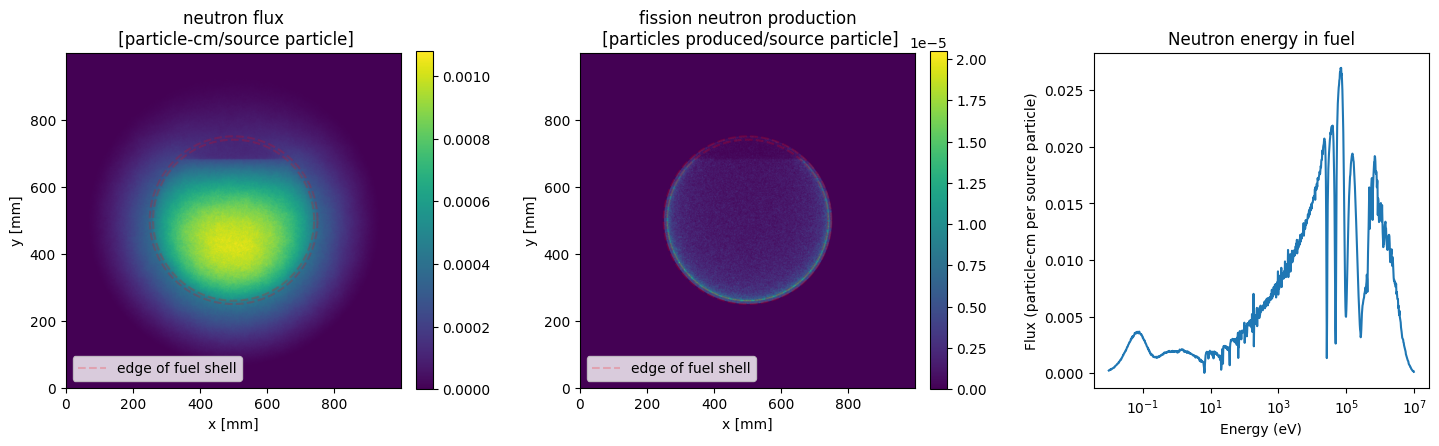

In [7]:
#print(sp.tallies.keys())
def plotCircle(ax ,r ,mesh_size ,resolution, label=False):
    theta = np.linspace(0, 2*np.pi, 200)
    x = (r * np.cos(theta)+mesh_size)*resolution/2
    y = (r * np.sin(theta)+mesh_size)*resolution/2
    if label:
        ax.plot(x,y,'r--',alpha=0.2,label="edge of fuel shell")
    else:
        ax.plot(x,y,'r--',alpha=0.2)
    return (x,y)

tally = sp.get_tally(id=2)
#print(tally)


flux = tally.get_slice(scores=['flux'])
fission = tally.get_slice(scores=['fission'])

flux.std_dev.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
flux.mean.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
fission.std_dev.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
fission.mean.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)

#Setting up figures using gridspec
fig = plt.figure(figsize=(18,6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1,1,1], wspace=0.4)



ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax0.set_title("neutron flux\n [particle-cm/source particle]")
im0=ax0.imshow(flux.mean, origin='lower')
plotCircle(ax0, inner_fuel_radius, mesh_size, resolution_of_mesh)
plotCircle(ax0, outer_fuel_radius, mesh_size, resolution_of_mesh, label=True)

ax0.set_xlabel('x [mm]')
ax0.set_ylabel('y [mm]')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
ax0.legend(loc='lower left')

ax1.set_title("fission neutron production\n [particles produced/source particle]")
im1=ax1.imshow(fission.mean, origin='lower')
plotCircle(ax1, inner_fuel_radius, mesh_size, resolution_of_mesh)
plotCircle(ax1, outer_fuel_radius, mesh_size, resolution_of_mesh, label=True)

ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.legend(loc='lower left')



# Create log-spaced energy bins from 1 keV to 10 MeV
energy_bins = np.logspace(3,7)

tally1=sp.get_tally(id=1)
#print(tally1.get_pandas_dataframe())

flux1 = tally1.get_pandas_dataframe()


ax2.plot(flux1['energy low [eV]'],flux1['mean'])

# Plot source energy PDF

ax2.set_xscale('log')  # log scale for x-axis
ax2.set_xlabel('Energy (eV)')
ax2.set_ylabel('Flux (particle-cm per source particle)')
ax2.set_title("Neutron energy in fuel")
#ax2.set_title("Neutron energy in moderator")
pos = ax0.get_position()  # returns [left, bottom, width, height]
pos2 = ax2.get_position()
# Set ax2 to have the same vertical position/height
ax2.set_position([pos2.x0, pos.y0, pos.width, pos.height])

In [8]:
#fig.savefig("Fourth_test_of_moderator_height.svg", format="svg")